In [5]:
library(tidyverse)

In [4]:
plots_dir <- "plots/"
dir.create(plots_dir)

Warning message in dir.create(plots_dir):
“'plots' already exists”


In [6]:
produce_gsea_plot <- function(ora_res_path, odds_threshold = 0.5, padj_thresh = 1e-5) {
    ora_res_df <- read.csv(ora_res_path)

    # filter out the low significant 
    ora_res_df <- ora_res_df[(ora_res_df$`Adjusted.P.value` < padj_thresh) & (ora_res_df$Odds.Ratio > odds_threshold), ]
    ora_res_df$`Adjusted.P.value` <- ora_res_df$`Adjusted.P.value` + 1e-20
    ora_res_df$log10_padj <- -1 * log10(ora_res_df$`Adjusted.P.value`)

    p1 <- ggplot(data = ora_res_df, 
               mapping = aes(x = cluster, 
                             y = Term, 
                             size = log10_padj,  # or pvalue instead of padj
                             fill = Odds.Ratio)) + 
          geom_point(shape = 21, color = "black") +  # shape 21 allows both fill and color
          scale_size_continuous(name = "-log10(p-value)", 
                               limits = c(1.5, 20)) +
          scale_fill_gradient2(low = "blue", 
                               mid = "white", 
                               high = "red", 
                               midpoint = 1,
                               limits = c(1, 10),
                               oob = scales::squish,
                               name = "Odds Ratio") + 
        theme_bw() + 
          theme(legend.text = element_text(size = 16), 
                 legend.title = element_text(size = 16, color = "black"), 
                 plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
                 axis.title.x = element_text(size = 16, color = "black"),
                 axis.title.y = element_text(size = 16, color = "black"),
                 axis.text.x = element_text(size = 16, color = "black"),
                 axis.text.y = element_text(size = 16, color = "black"),
        	 strip.text = element_text(size = 18, color = "black"),
        strip.background = element_blank()) + 
          theme(axis.text.x = element_text(angle = 45, hjust = 1))
    
    return(p1)
}

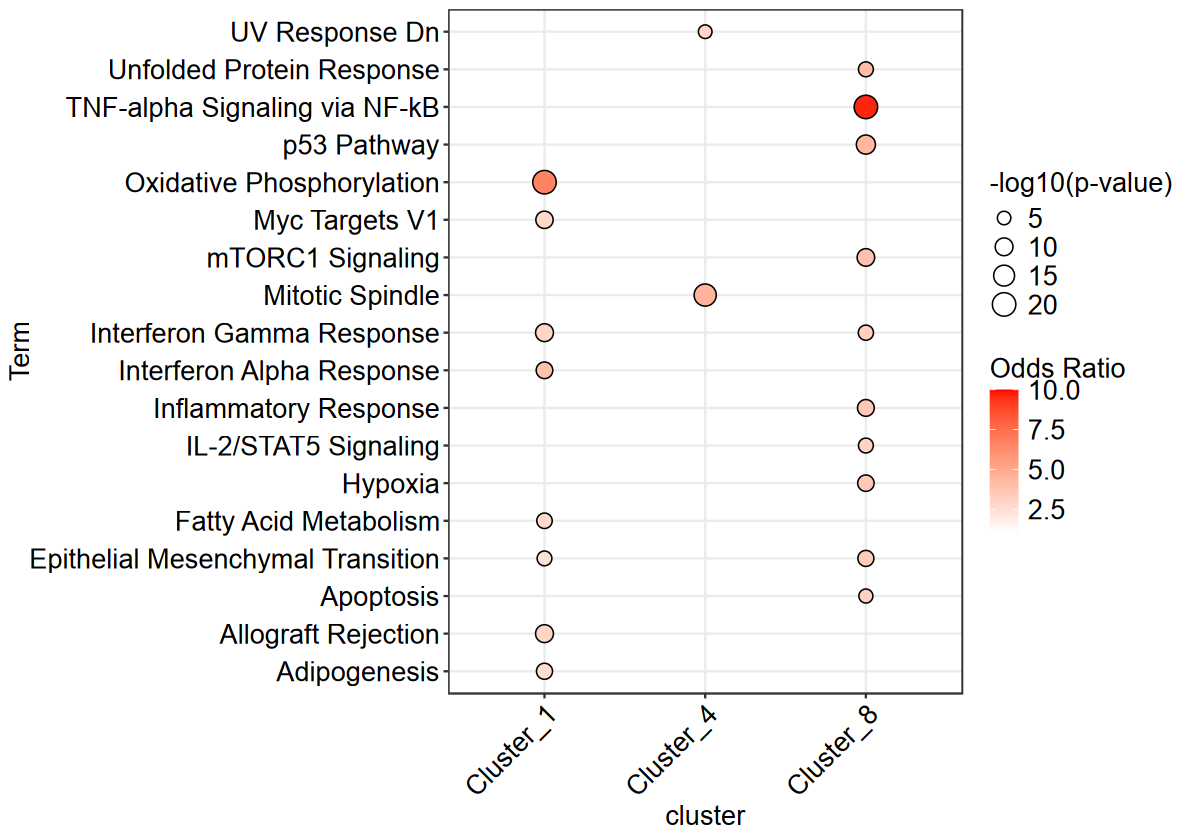

In [7]:
options(repr.plot.width = 10, repr.plot.height = 7)
# test for one
produce_gsea_plot(ora_res_path = "trajectory_res/Cardiomyocyte/Cardiomyocyte_postnatal:DCM_ora_res.csv")

In [9]:
read.csv("trajectory_res/Fibroblast/Fibroblast_fetal:ND_ora_res.csv")$cluster

[1] "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2"
 [7] "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2"
[13] "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2" "Cluster_2"
[19] "Cluster_2" "Cluster_2" "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3"
[25] "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3"
[31] "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3"
[37] "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3" "Cluster_3"
[43] "Cluster_3" "Cluster_4" "Cluster_4" "Cluster_4" "Cluster_4" "Cluster_4"
[49] "Cluster_4" "Cluster_4" "Cluster_4" "Cluster_4" "Cluster_4" "Cluster_4"
[55] "Cluster_5" "Cluster_5" "Cluster_5" "Cluster_5" "Cluster_5" "Cluster_5"

In [10]:
cell_types <- c("Cardiomyocyte", "Endothelial", "Fibroblast", "Myeloid")
disease_groups <- c("postnatal:DCM", "postnatal:ICM", "postnatal:HCM", "fetal:ND")

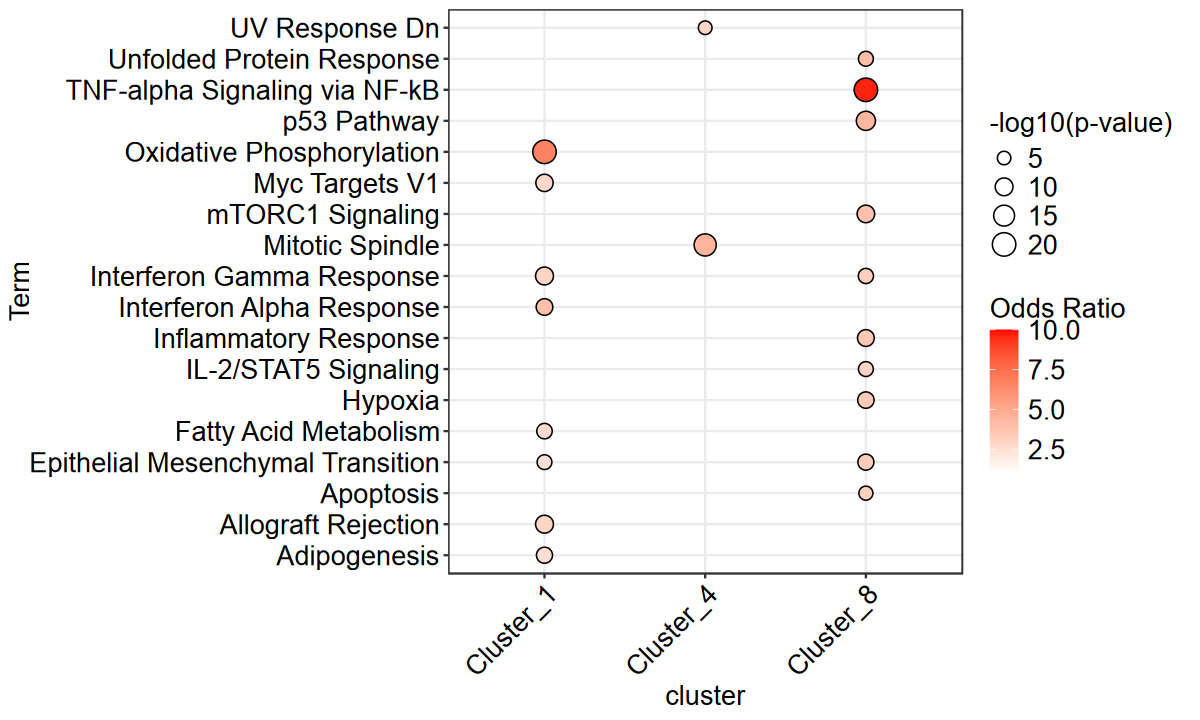

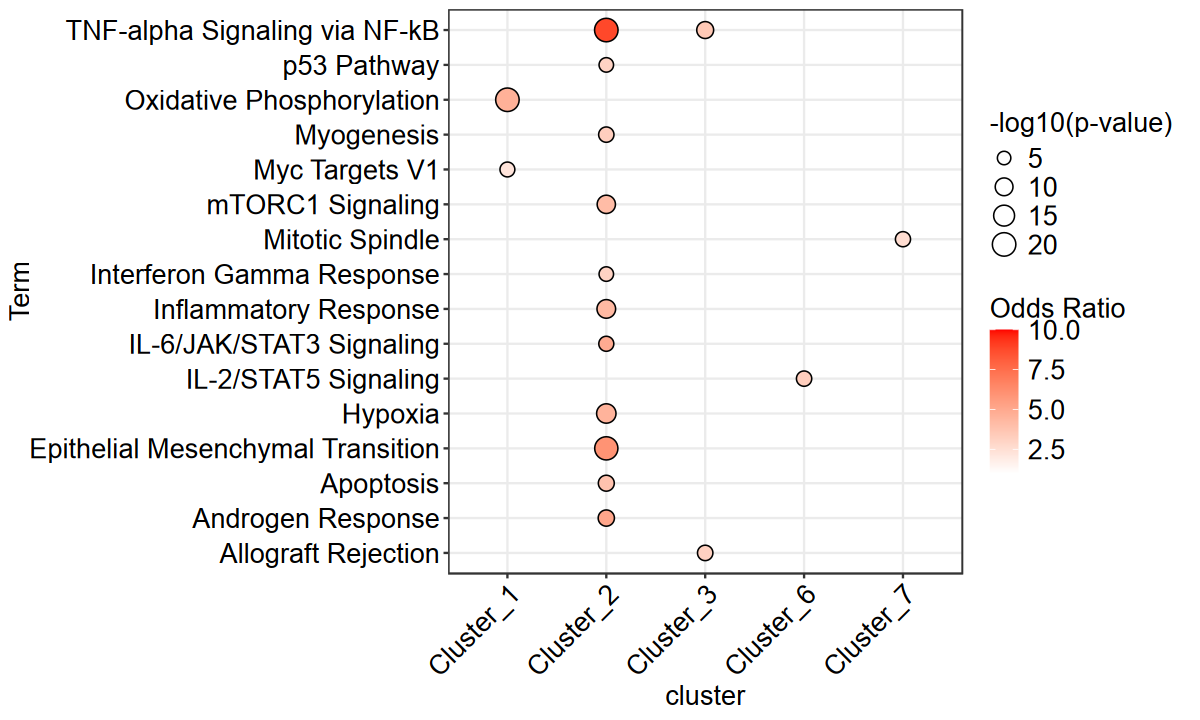

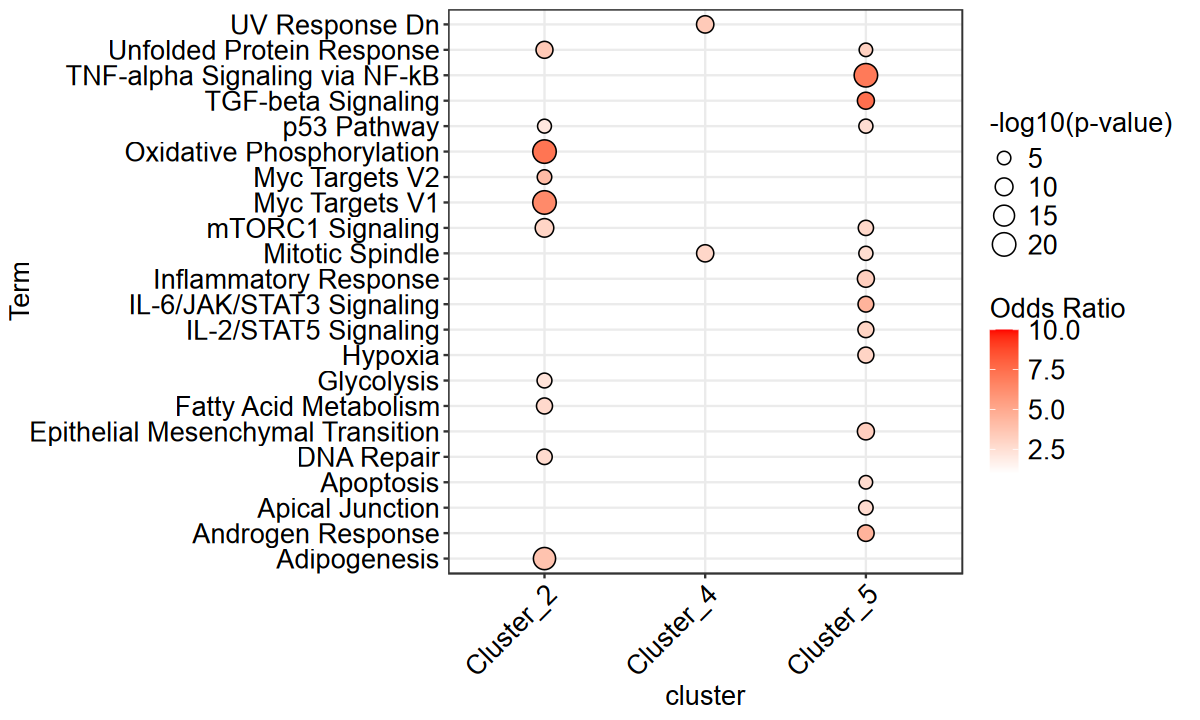

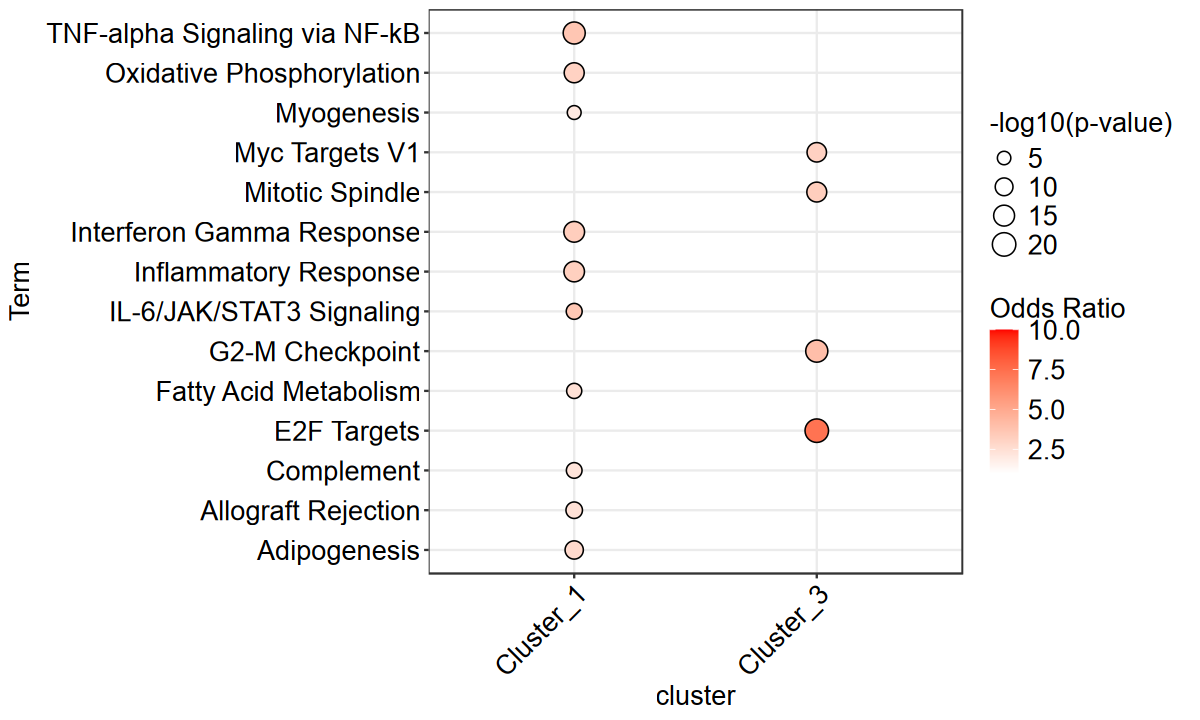

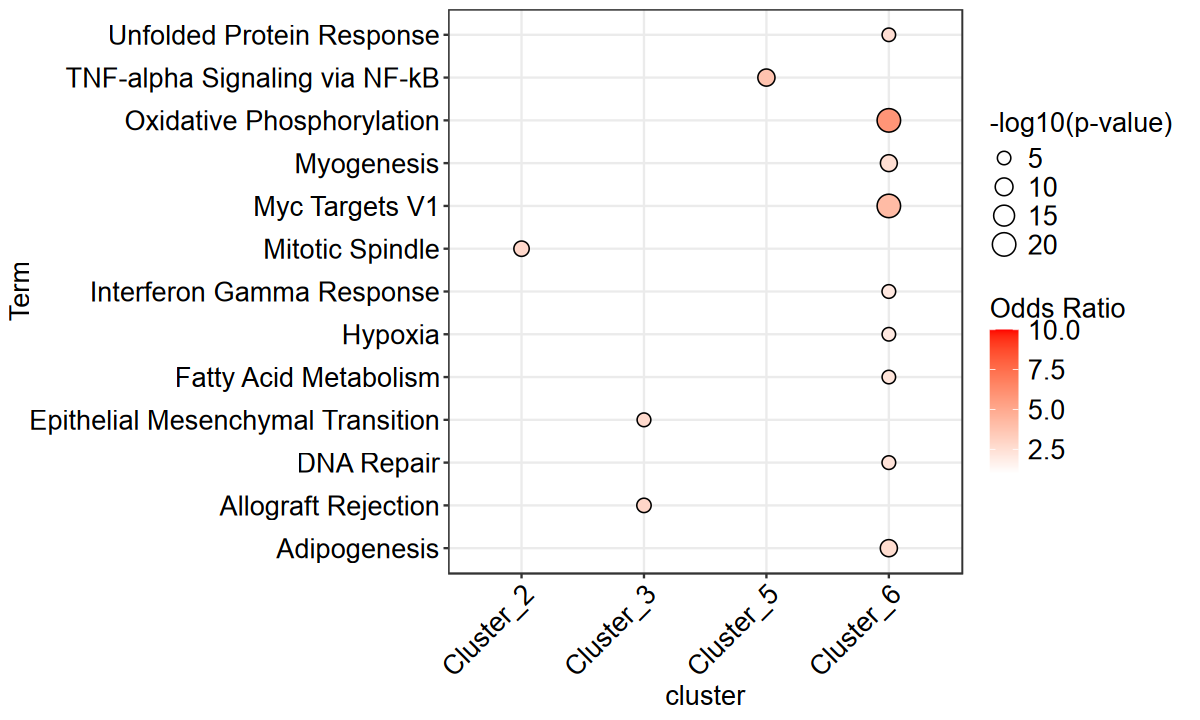

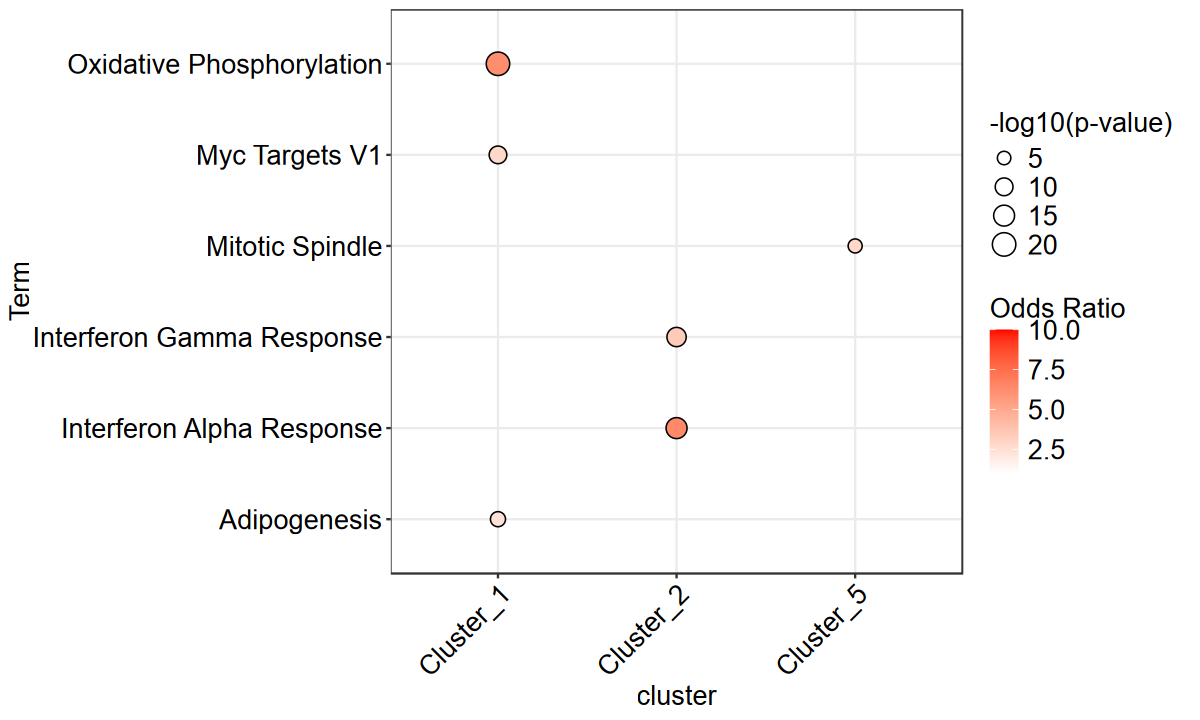

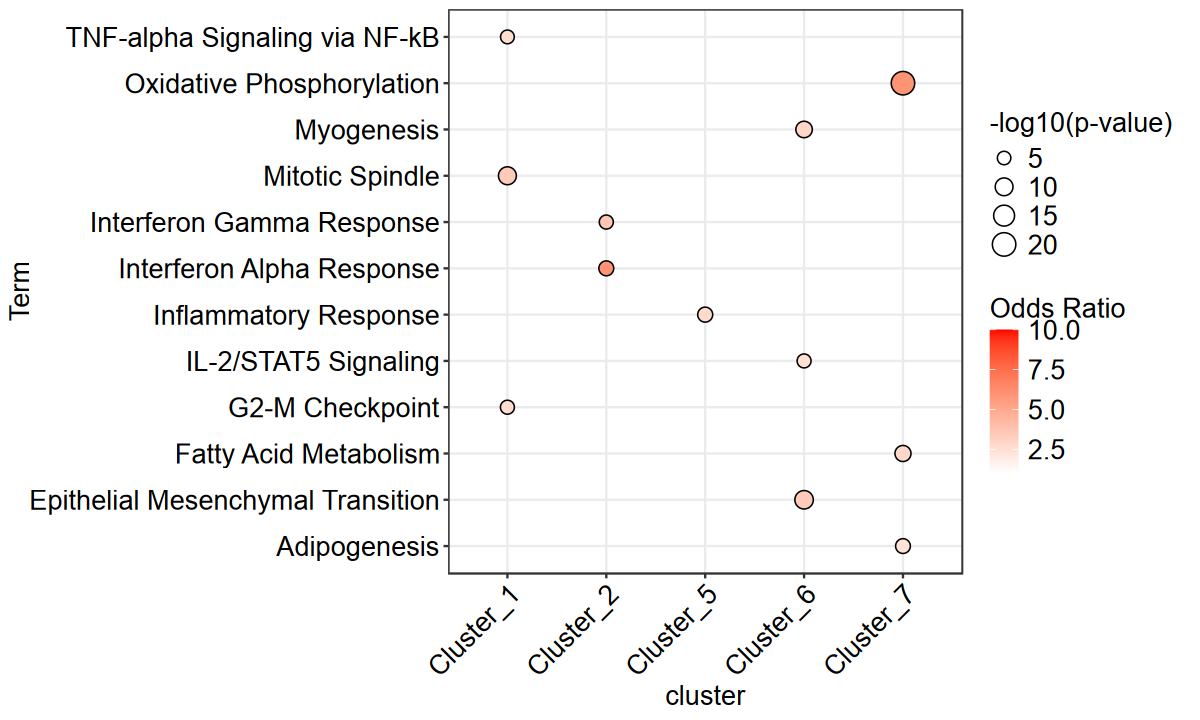

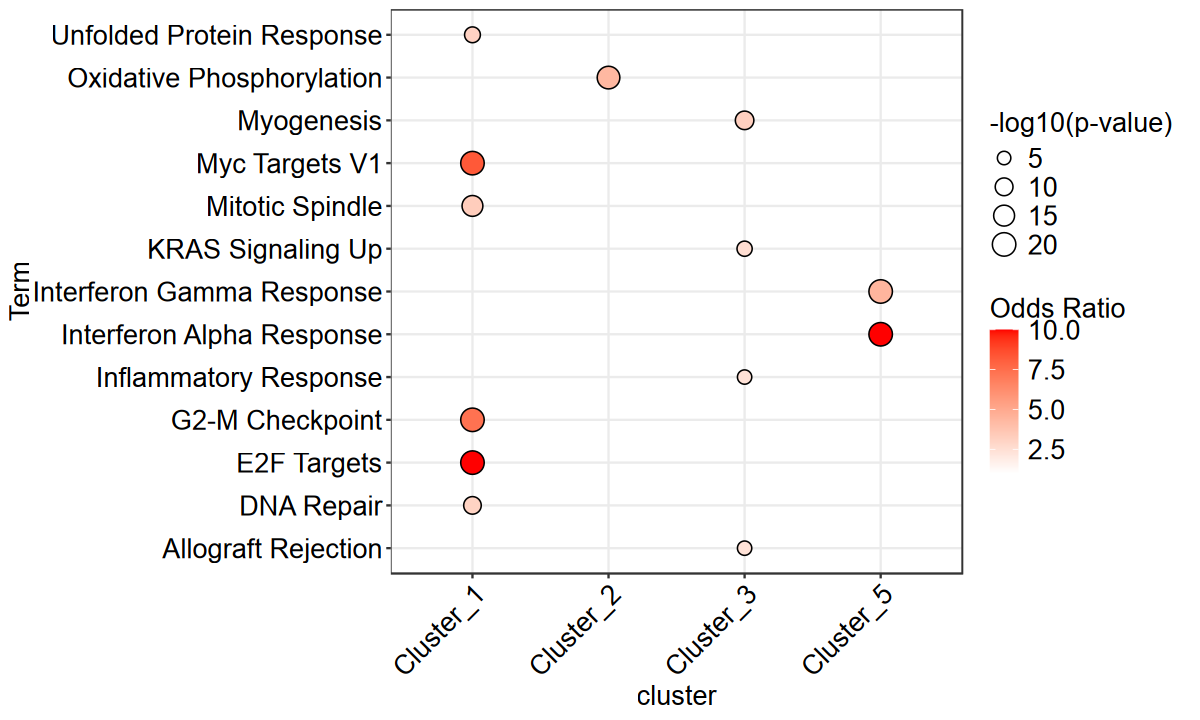

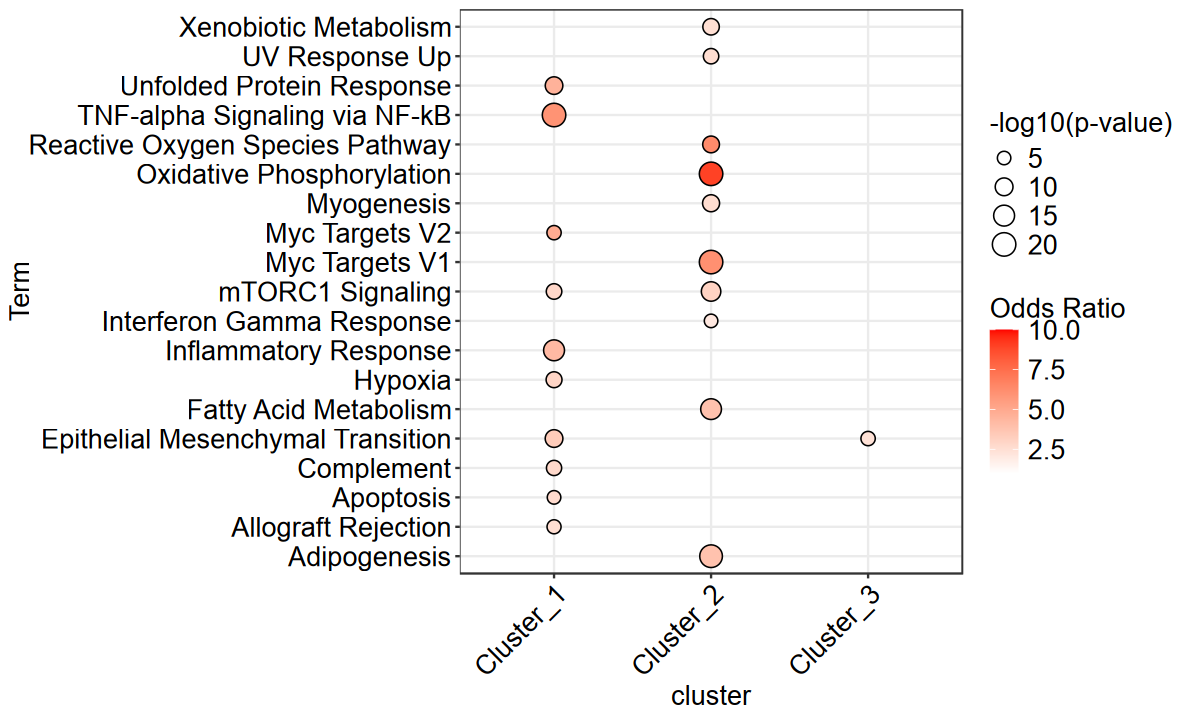

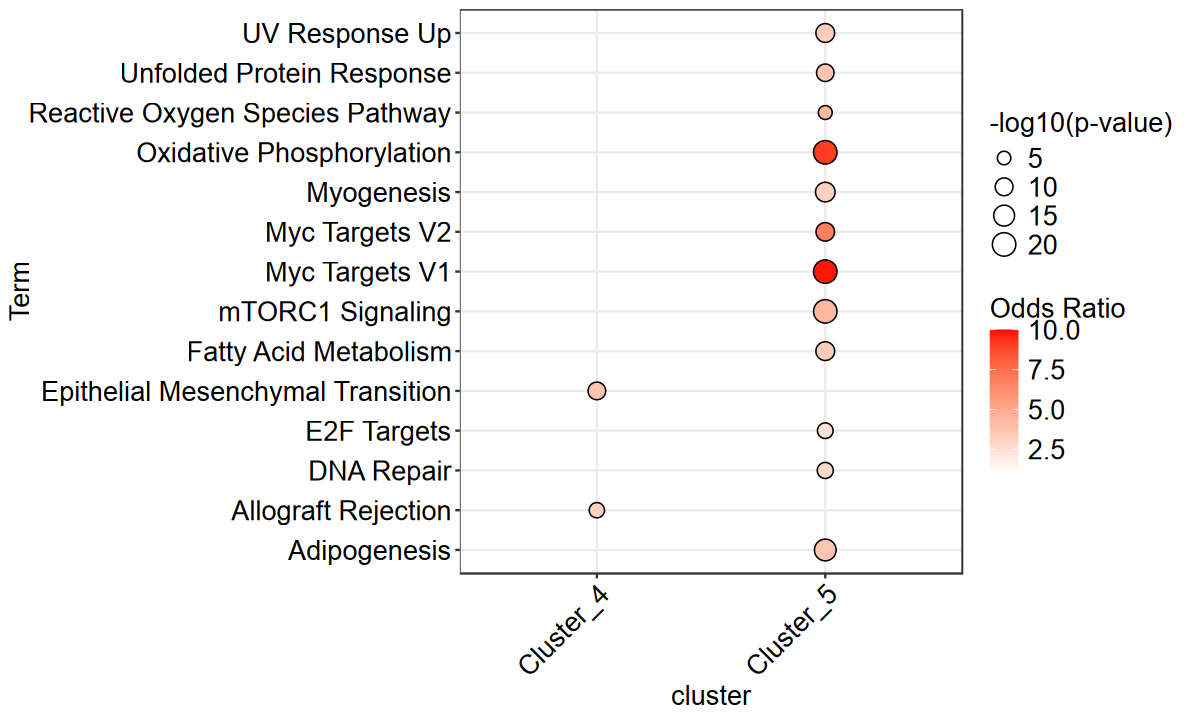

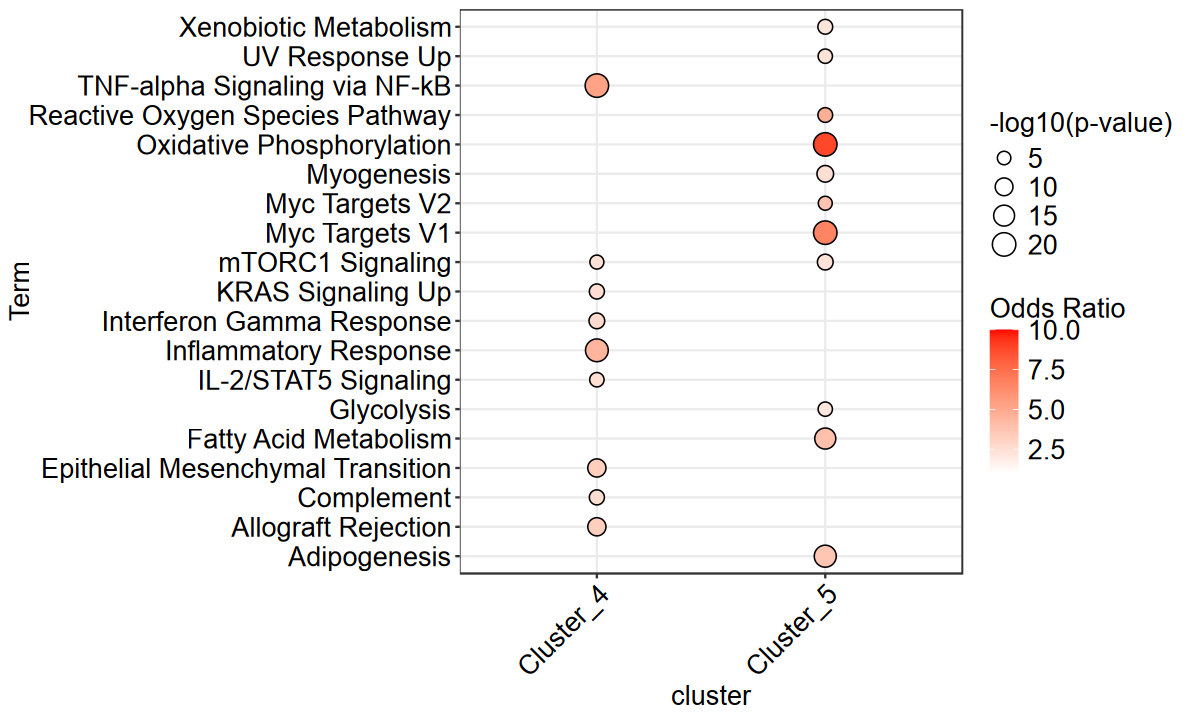

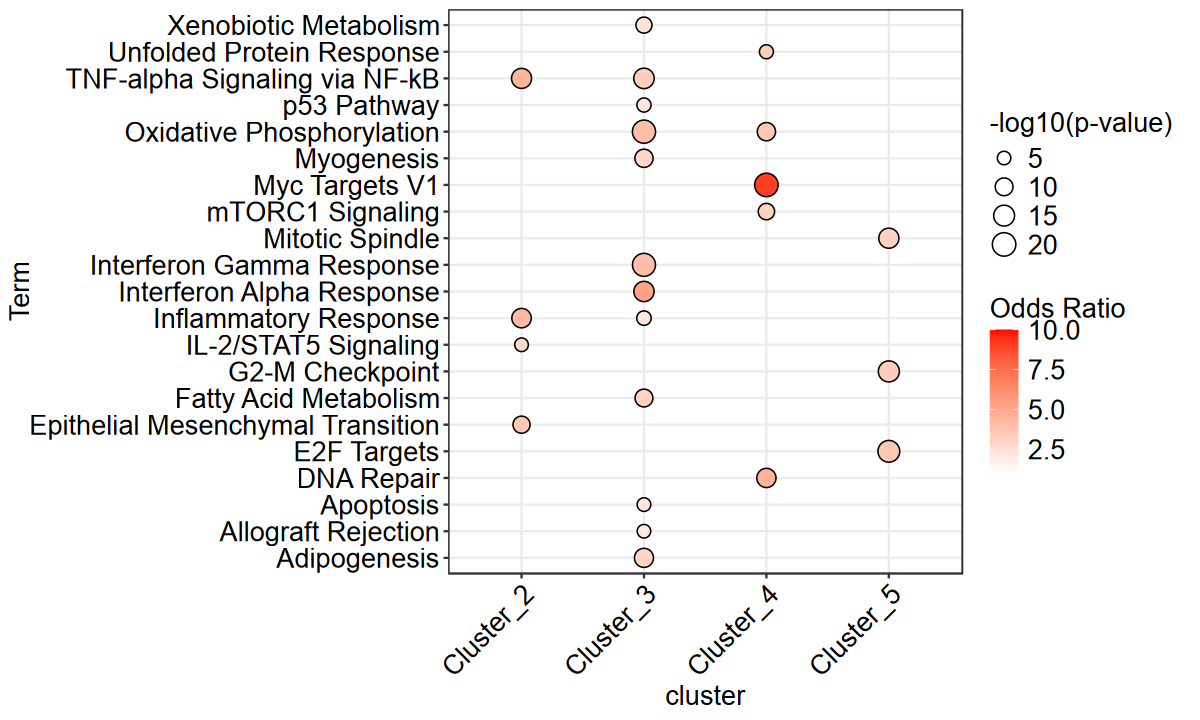

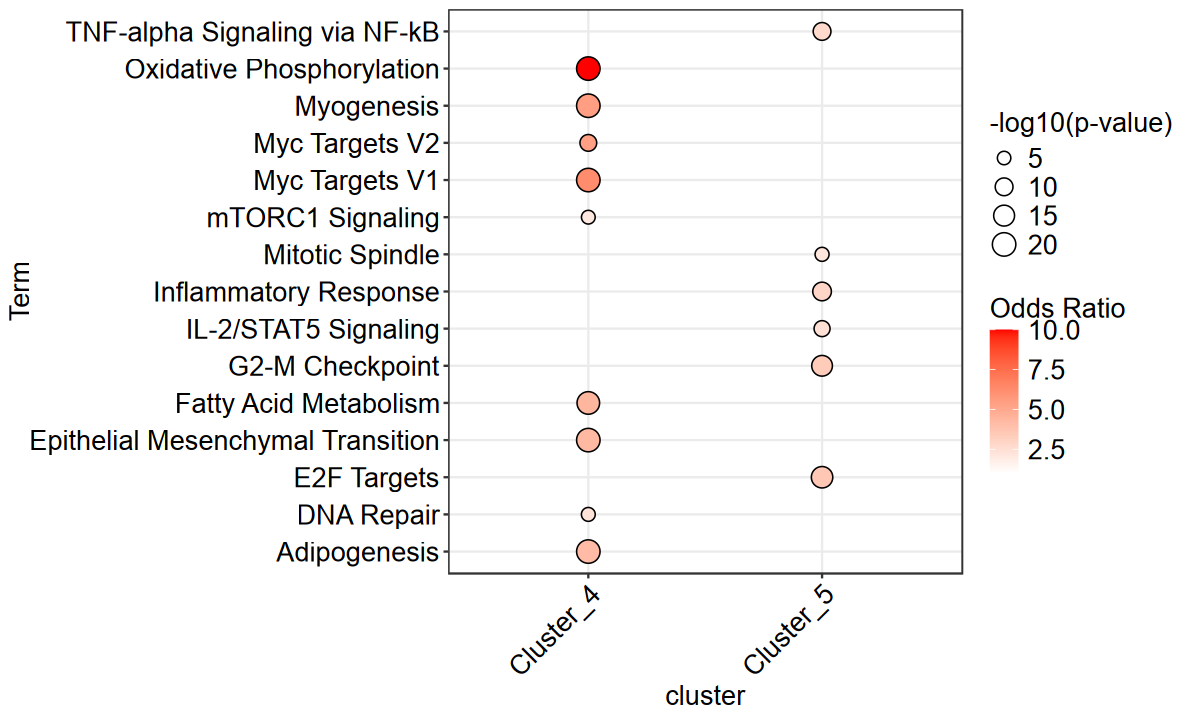

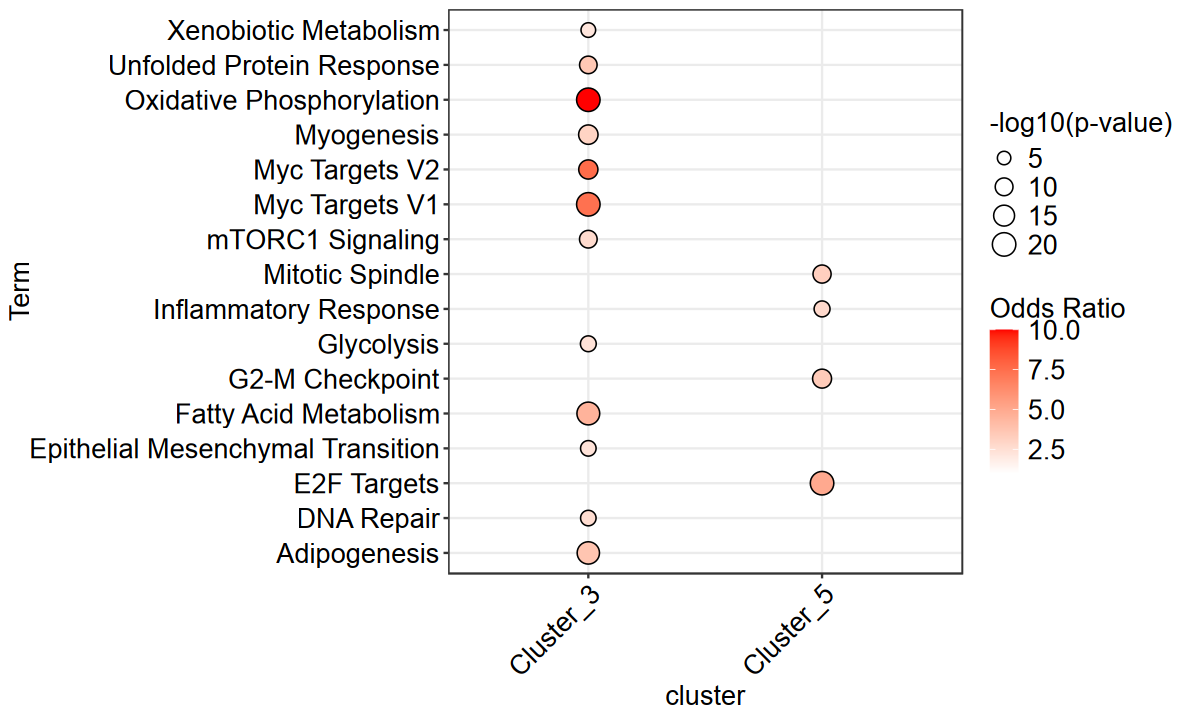

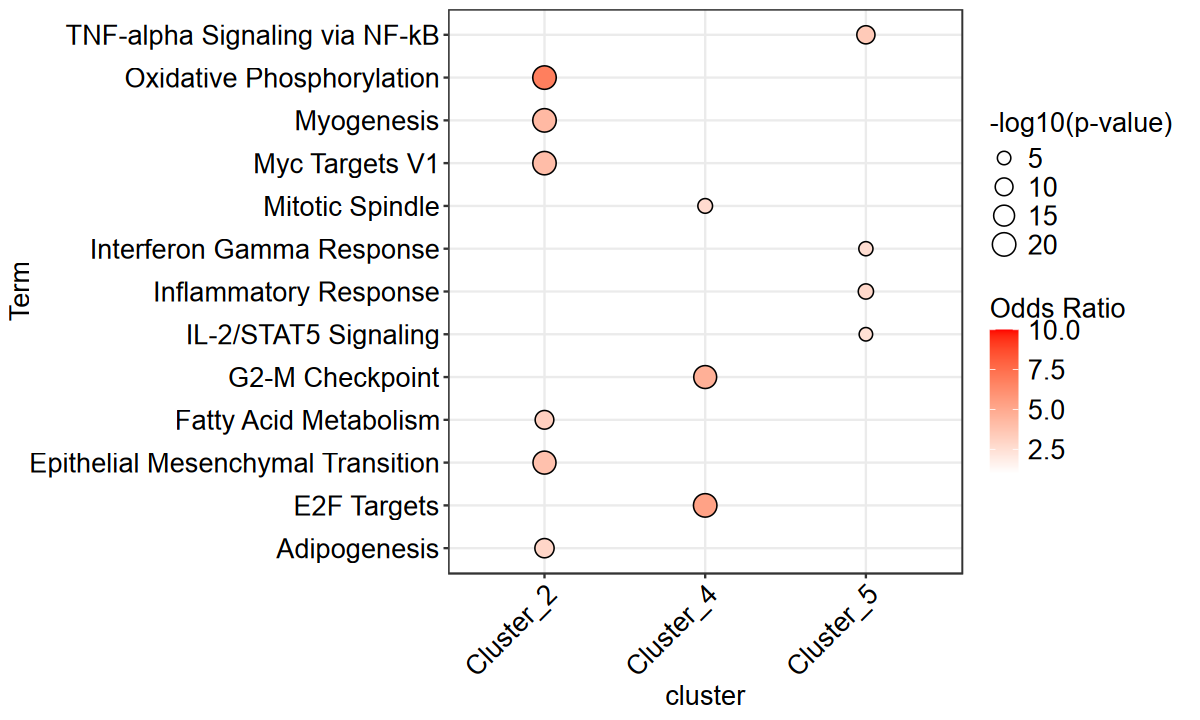

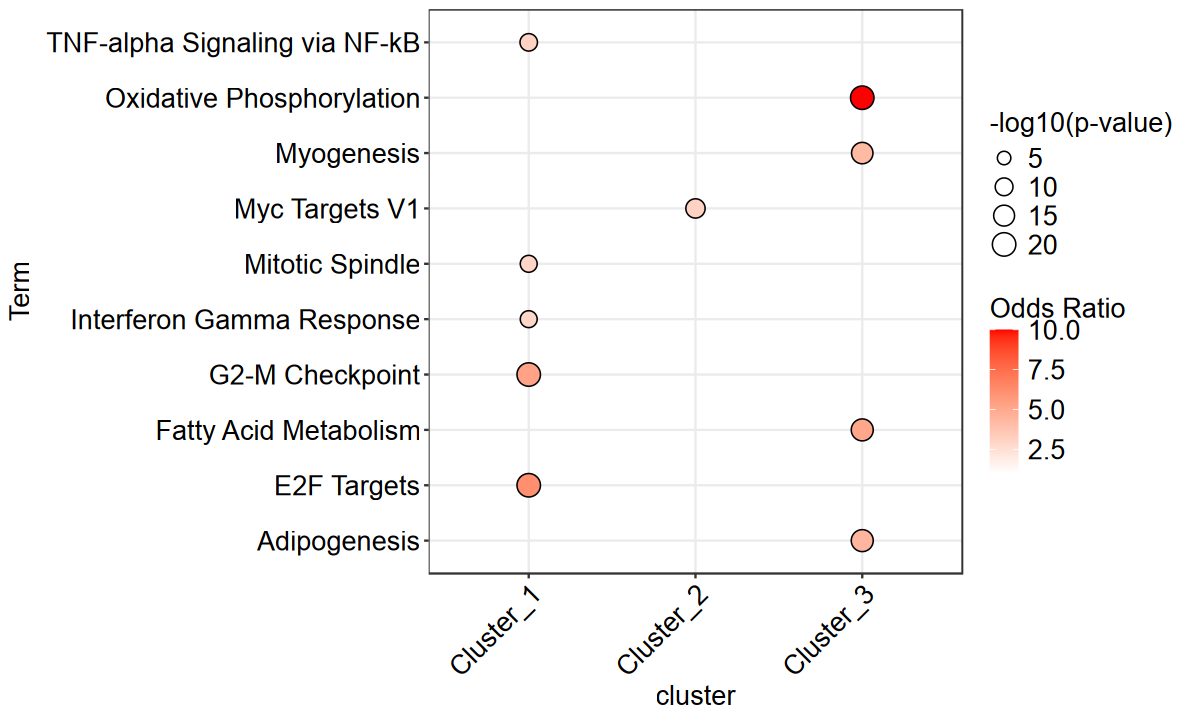

In [11]:
options(repr.plot.width = 10, repr.plot.height = 6)

for (cell_type in cell_types) {
    for (disease in disease_groups) {
        p1 <- produce_gsea_plot(ora_res_path = paste0("trajectory_res/", cell_type, "/", cell_type, "_", disease, "_ora_res.csv"))
        print(p1)
        ggsave(p1, filename = paste0(plots_dir, "ora_res", cell_type, "_", disease, ".pdf"), width = 10, height = 7)
    }
}

In [12]:
#produce_gsea_plot(ora_res_path = "trajectory_res/Fibroblast/Fibroblast_fetal:ND_ora_res.csv")

In [9]:
#fetal_gene_cor_df <- read.csv("trajectory_res/Cardiomyocyte/Cardiomyocyte_fetal:ND_gene_correlations.csv", row.names = 1)
#DCM_gene_cor_df <- read.csv("trajectory_res/Cardiomyocyte/Cardiomyocyte_postnatal:DCM_gene_correlations.csv", row.names = 1)

In [10]:
#common_genes <- intersect(rownames(DCM_gene_cor_df), rownames(fetal_gene_cor_df))

#df <- data.frame(
#  gene = common_genes,
#  spearman_DCM   = DCM_gene_cor_df[common_genes, "spearman_r"],
#  spearman_fetal = fetal_gene_cor_df[common_genes, "spearman_r"]
#)

#df <- na.omit(df)

In [11]:
#cor(df$spearman_DCM, df$spearman_fetal)

In [12]:
#df

In [13]:
#options(repr.plot.width = 5, repr.plot.height = 5)
#ggplot(data = df, mapping = aes(x = spearman_DCM, y = spearman_fetal)) + geom_point() + theme_bw()